In [119]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [120]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [121]:
NUM_CLASSES = 9

# Dataset reading

In [122]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [123]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [125]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [126]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_10 (Dropout)        (None, 42)                0         
                                                                 
 dense_15 (Dense)            (None, 20)                860       
                                                                 
 dropout_11 (Dropout)        (None, 20)                0         
                                                                 
 dense_16 (Dense)            (None, 10)                210       
                                                                 
 dense_17 (Dense)            (None, 9)                 99        
                                                                 
Total params: 1169 (4.57 KB)
Trainable params: 1169 (4.57 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [127]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [128]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [129]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
56/63 [=========================>....] - ETA: 0s - loss: 2.2127 - accuracy: 0.1338
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
63/63 [==============================] - 1s 5ms/step - loss: 2.2066 - accuracy: 0.1360 - val_loss: 2.1117 - val_accuracy: 0.1623
Epoch 2/1000
56/63 [=========================>....] - ETA: 0s - loss: 2.1026 - accuracy: 0.1854
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5


d:\University\Embedded Systems\Project\Vision\smart-class-project\ai-model\hand-gesture-recognition-mediapipe\venv310\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


63/63 [==============================] - 0s 3ms/step - loss: 2.1012 - accuracy: 0.1880 - val_loss: 2.0214 - val_accuracy: 0.2465
Epoch 3/1000
51/63 [=======================>......] - ETA: 0s - loss: 2.0311 - accuracy: 0.2223
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
63/63 [==============================] - 0s 3ms/step - loss: 2.0215 - accuracy: 0.2268 - val_loss: 1.9127 - val_accuracy: 0.3507
Epoch 4/1000
55/63 [=========================>....] - ETA: 0s - loss: 1.9327 - accuracy: 0.2626
Epoch 4: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
63/63 [==============================] - 0s 3ms/step - loss: 1.9255 - accuracy: 0.2652 - val_loss: 1.7670 - val_accuracy: 0.4130
Epoch 5/1000
56/63 [=========================>....] - ETA: 0s - loss: 1.8346 - accuracy: 0.3145
Epoch 5: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
63/63 [==============================] - 0s 3ms/step - loss: 1.8323 - accuracy: 0.3151 - val_loss

In [130]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

21/21 [==============================] - 0s 2ms/step - loss: 0.6465 - accuracy: 0.8309


In [131]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [132]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 58ms/step
[1.4468777e-01 9.3900971e-03 5.2902376e-04 2.3117136e-02 2.7279788e-01
 5.4881418e-01 6.2315684e-04 1.6046615e-06 3.9188137e-05]
5


# Confusion matrix

83/83 [==============================] - 0s 1ms/step


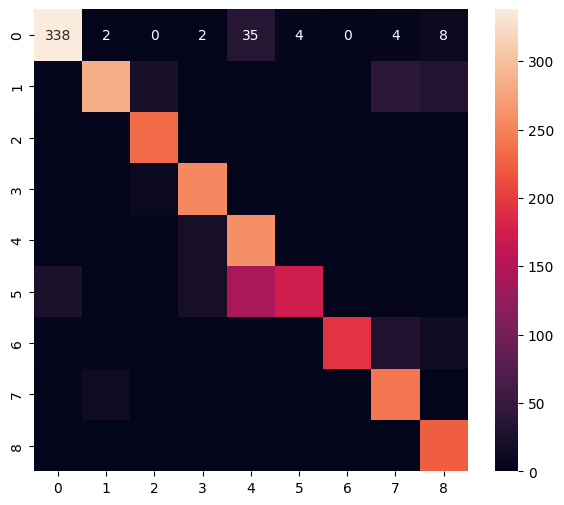

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       393
           1       0.93      0.74      0.83       383
           2       0.88      0.98      0.93       238
           3       0.85      0.97      0.91       263
           4       0.59      0.91      0.72       285
           5       0.97      0.48      0.64       365
           6       1.00      0.79      0.89       243
           7       0.76      0.95      0.84       255
           8       0.80      1.00      0.89       224

    accuracy                           0.83      2649
   macro avg       0.85      0.85      0.84      2649
weighted avg       0.86      0.83      0.83      2649



In [133]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [134]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

d:\University\Embedded Systems\Project\Vision\smart-class-project\ai-model\hand-gesture-recognition-mediapipe\venv310\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [135]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\Moham\AppData\Local\Temp\tmpvy3g9z5r\assets


INFO:tensorflow:Assets written to: C:\Users\Moham\AppData\Local\Temp\tmpvy3g9z5r\assets


6844

# Inference test

In [136]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [137]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [138]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [139]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 15.6 ms
Wall time: 0 ns


In [140]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.4468779e-01 9.3900943e-03 5.2902341e-04 2.3117132e-02 2.7279773e-01
 5.4881436e-01 6.2315643e-04 1.6046605e-06 3.9188148e-05]
5
